## Modelado con K-Means

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score
from matplotlib import cm
import plotly.express as px
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
import seaborn as sns



In [36]:
df_clustering = pd.read_csv('df_clustering_models.csv')
df_nutrients = pd.read_csv('df_nutrients_models.csv')


df_clustering_pca = df_clustering.copy()
df_clustering_pca.drop(columns=['folio_integrante','edad', 'ponderador'], inplace=True)

pipeline = Pipeline([
    ('scaler', RobustScaler()),       
    ('pca', PCA(n_components=0.90))   
])

# 2. Ajustar el pipeline a los datos
df_clustering_pca = pipeline.fit_transform(df_clustering_pca)

# Ver resultados
pca_model = pipeline.named_steps['pca']
print(f"Cantidad de componentes seleccionadas: {pca_model.n_components_}")
print(f"Porcentaje de varianza explicada: {pca_model.explained_variance_ratio_.sum() * 100:.2f}%")

df_clustering_pca = pd.DataFrame(df_clustering_pca, columns=[f"PC{i+1}" for i in range(pca_model.n_components_)])
df_clustering_pca.head()



Cantidad de componentes seleccionadas: 12
Porcentaje de varianza explicada: 90.12%


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12
0,-2.306317,0.317488,-0.697239,-0.523061,0.758163,0.708531,0.437985,0.797205,0.384570,-0.461784,-1.019971,0.726689
1,-2.309164,0.316490,-0.697543,-0.516964,0.755885,0.696534,0.415030,0.777980,0.363091,-0.428118,-1.056909,-0.684031
2,0.772588,1.536511,-0.178405,-0.287182,0.251287,0.878352,0.363130,0.646792,0.272111,-0.111743,0.369089,0.682202
3,0.769741,1.535513,-0.178709,-0.281086,0.249009,0.866354,0.340176,0.627567,0.250631,-0.078076,0.332150,-0.728517
4,-0.140615,-0.199725,2.446234,-0.183081,-0.921510,0.593478,0.252913,0.886035,-0.209380,0.366258,0.711844,0.703940


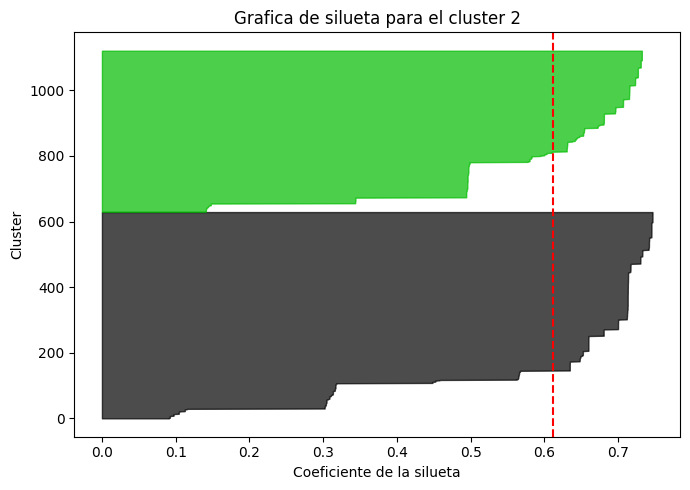

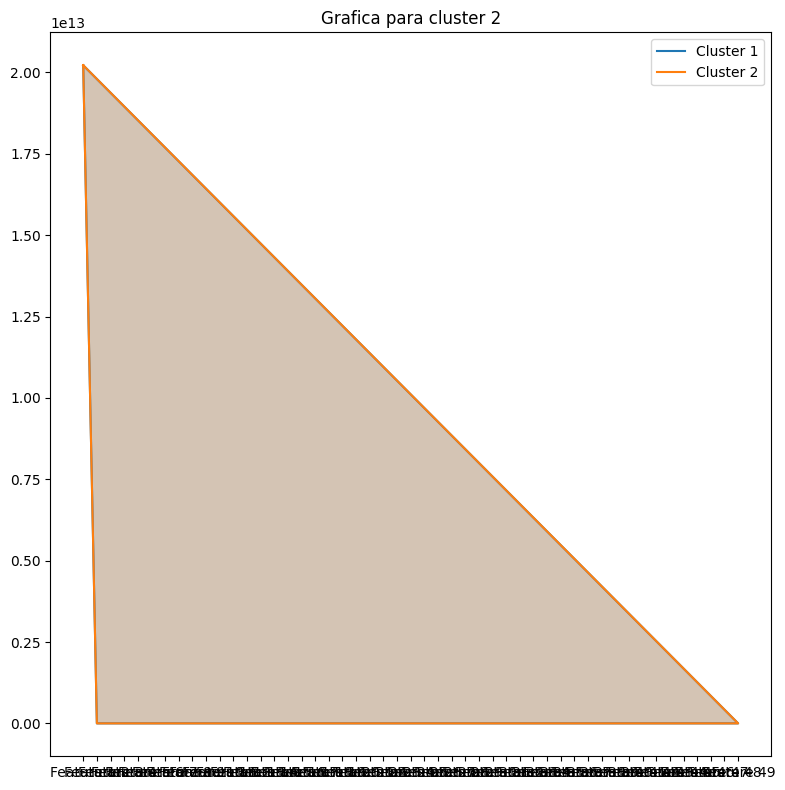

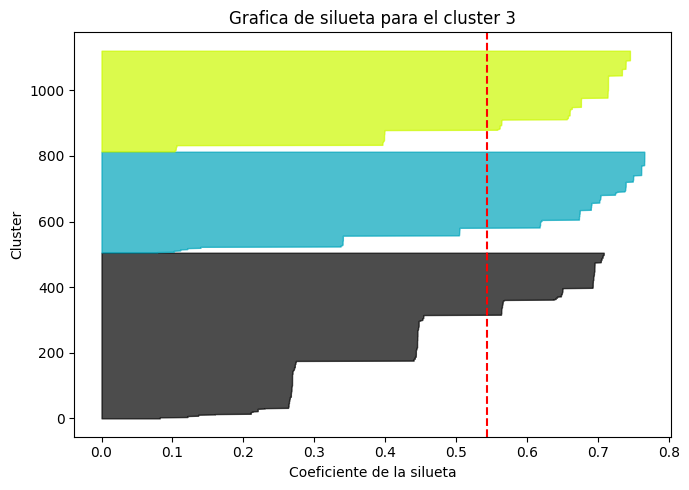

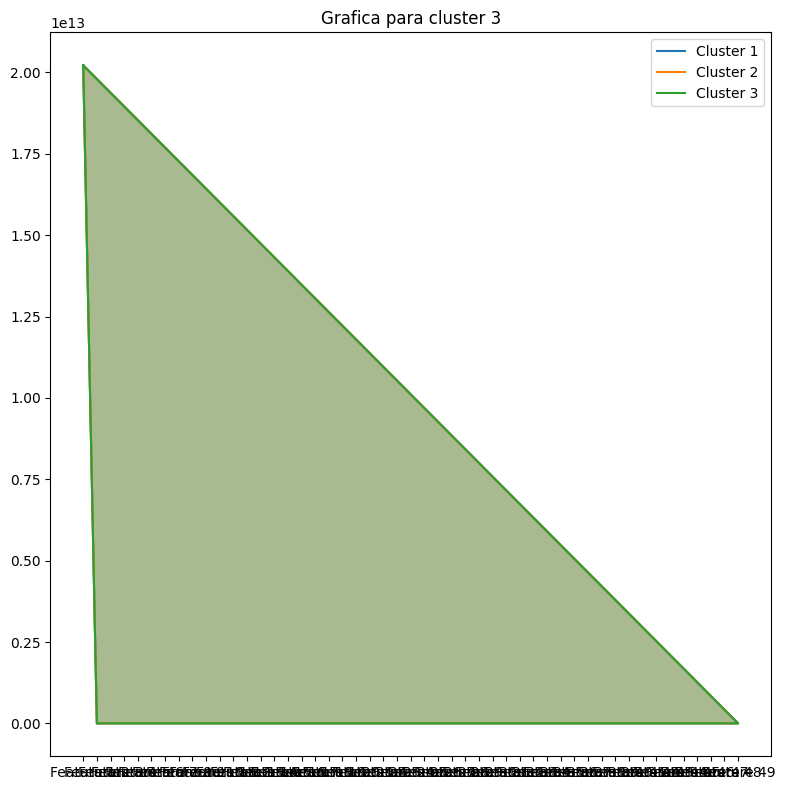

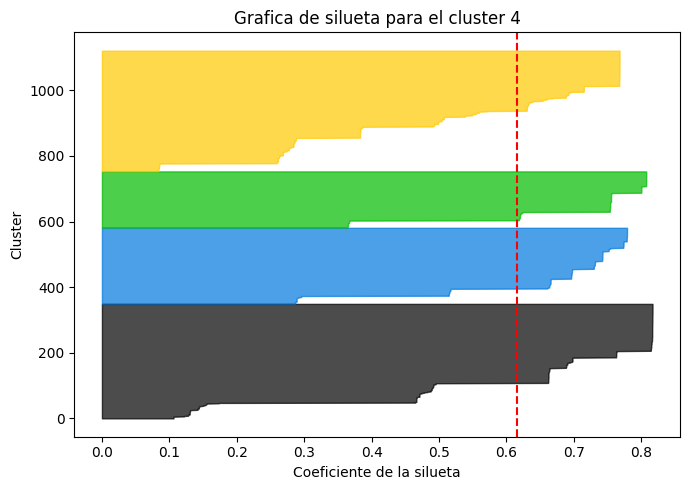

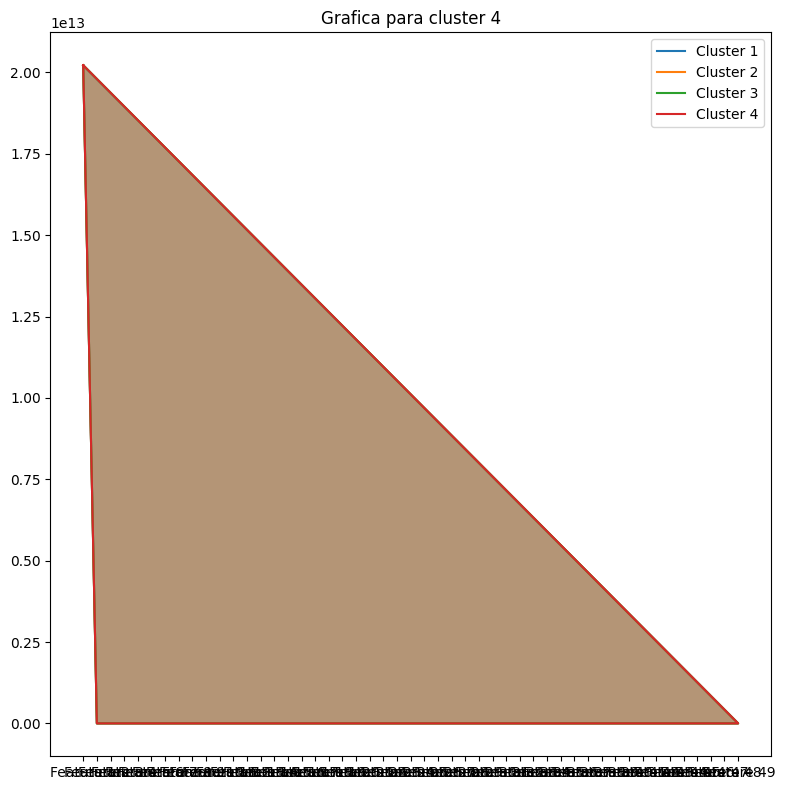

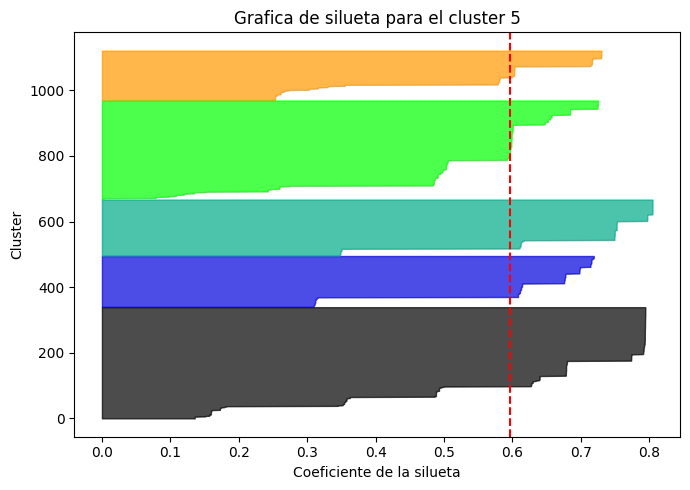

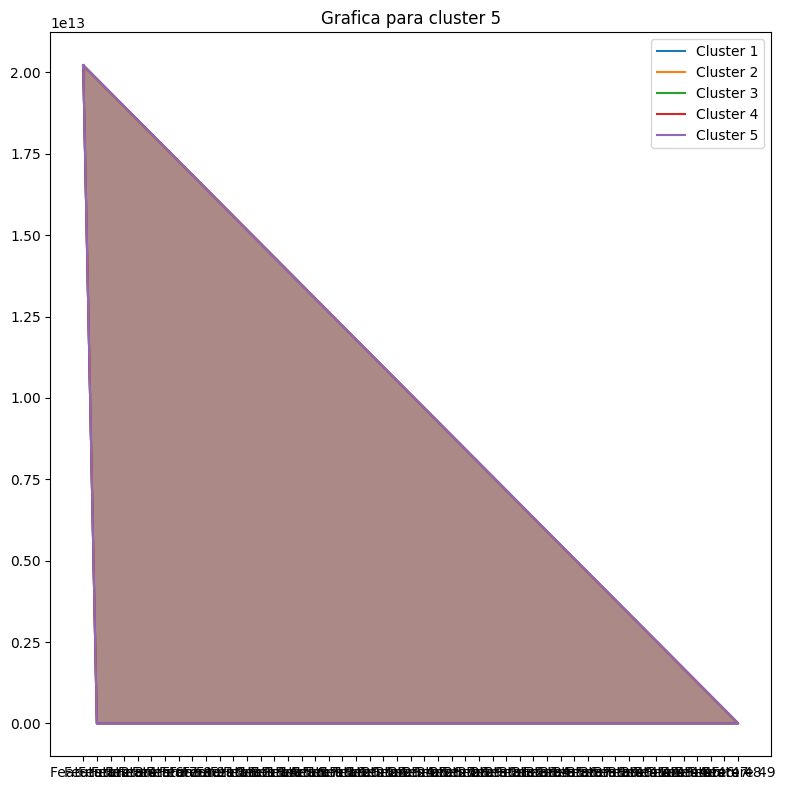

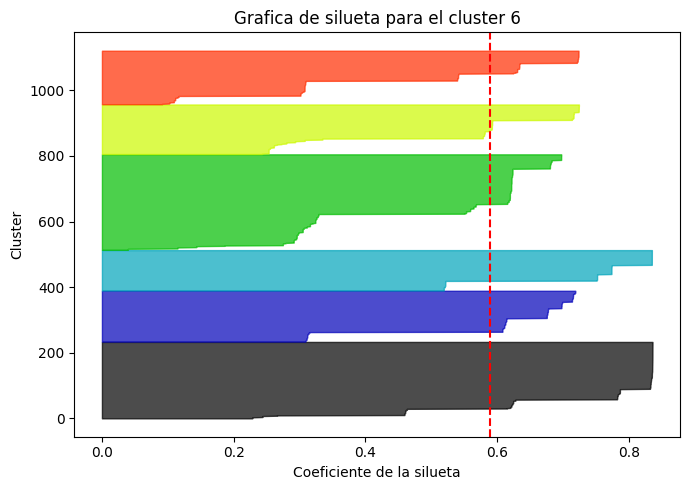

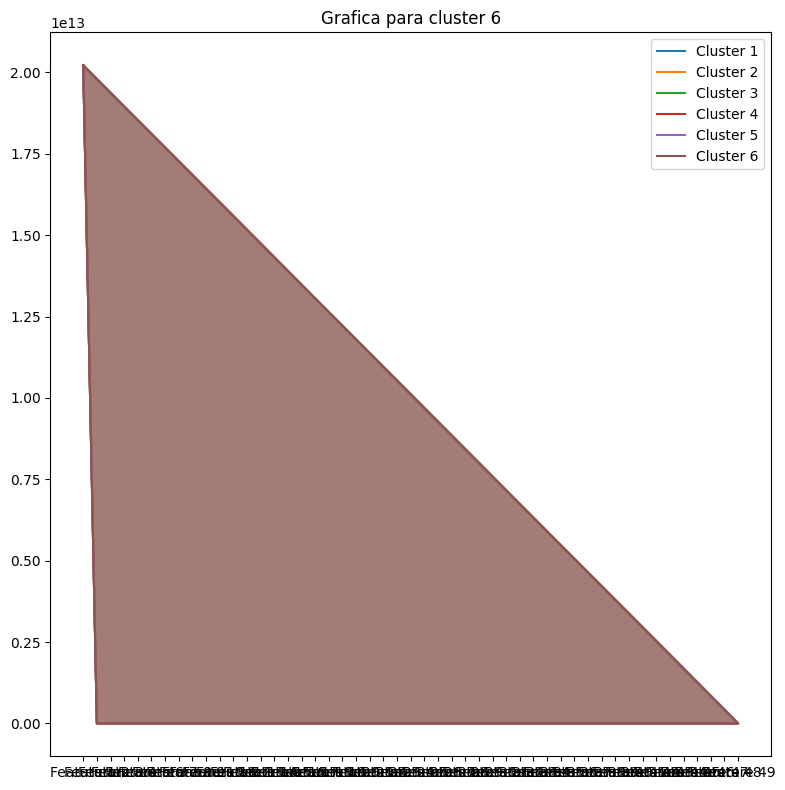

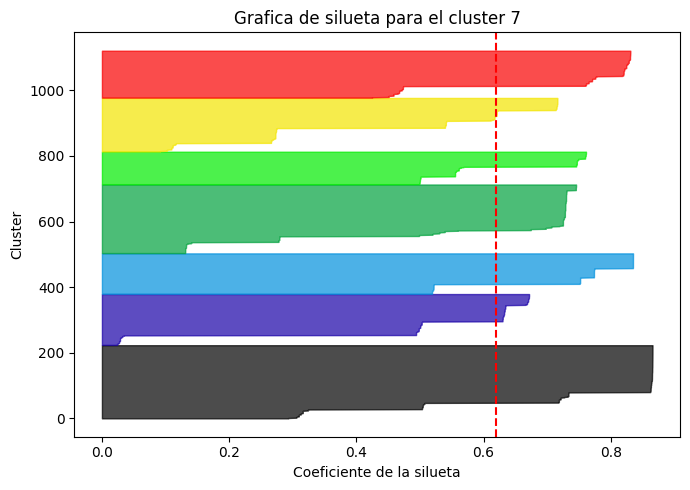

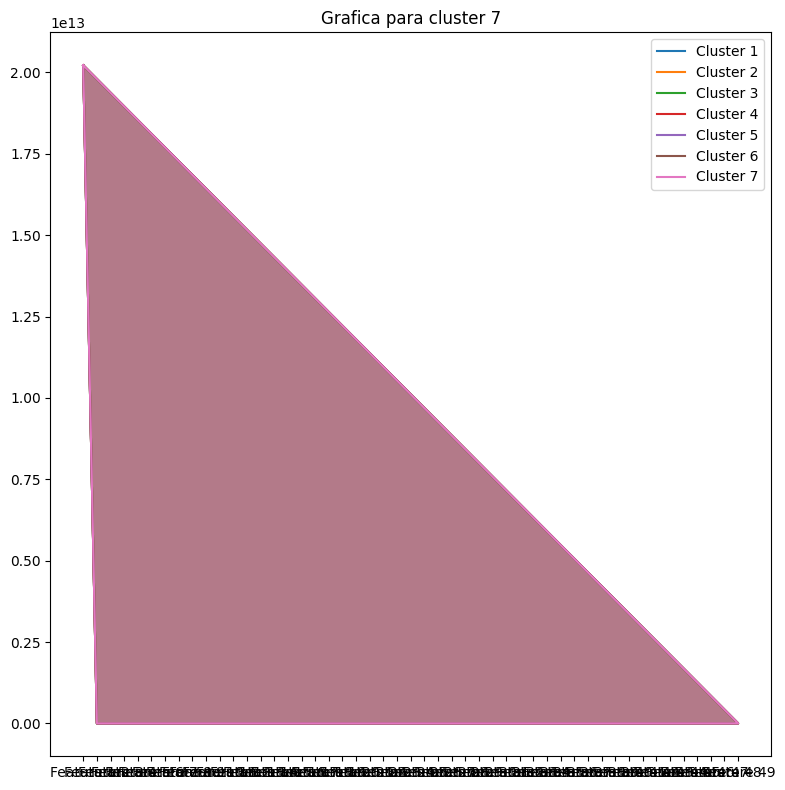

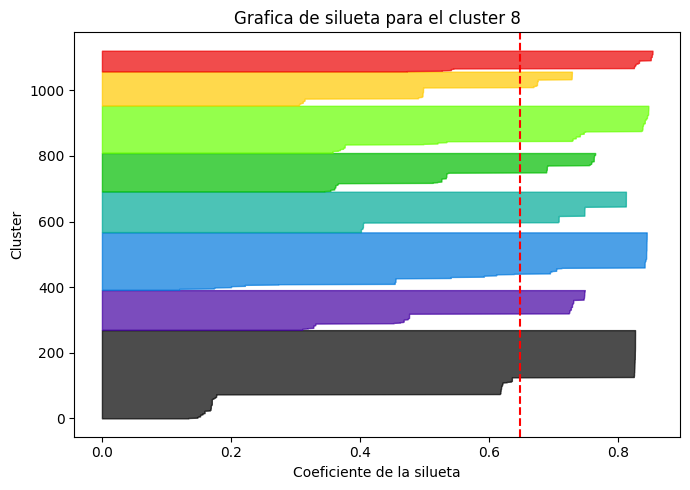

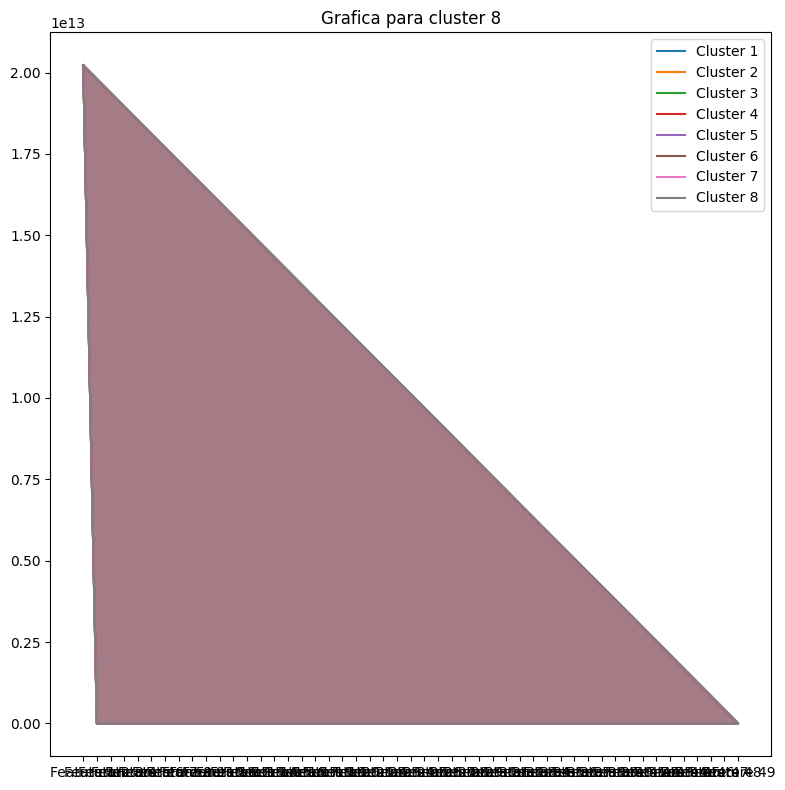

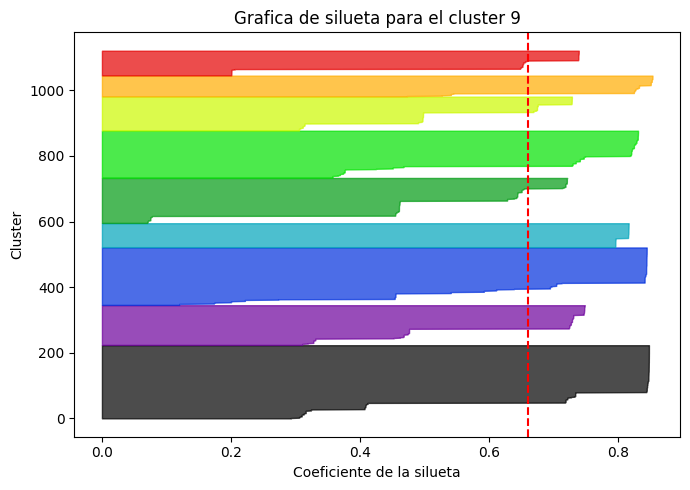

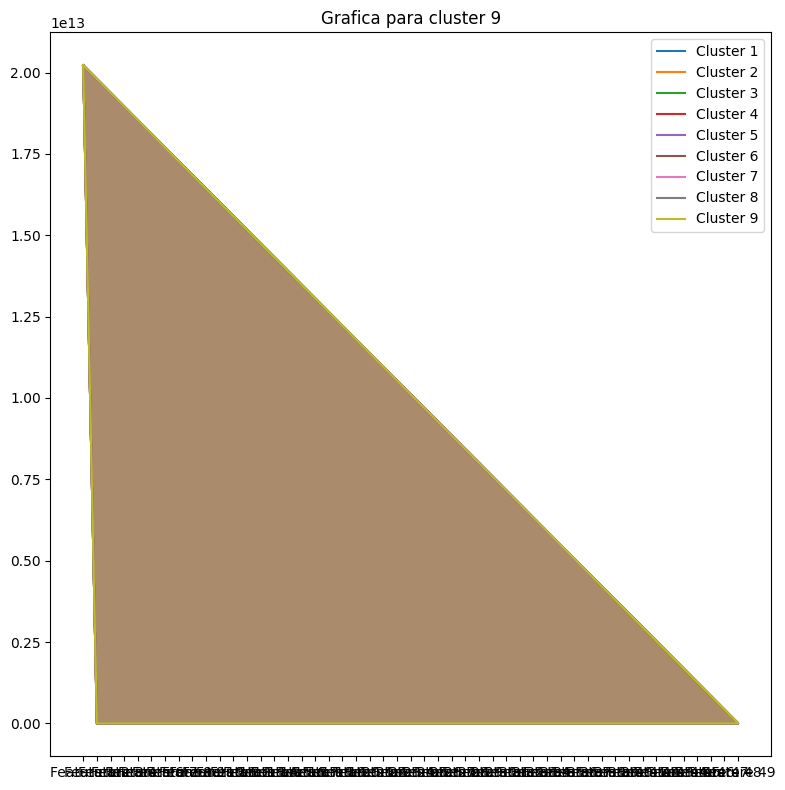

cluster = 2, Puntaje de Silueta = 0.6113153360447934
cluster = 3, Puntaje de Silueta = 0.5442395379275615
cluster = 4, Puntaje de Silueta = 0.6161972806678396
cluster = 5, Puntaje de Silueta = 0.5960095564538905
cluster = 6, Puntaje de Silueta = 0.5891009863706282
cluster = 7, Puntaje de Silueta = 0.6204040362937633
cluster = 8, Puntaje de Silueta = 0.6472779598418519
cluster = 9, Puntaje de Silueta = 0.6604722732327026


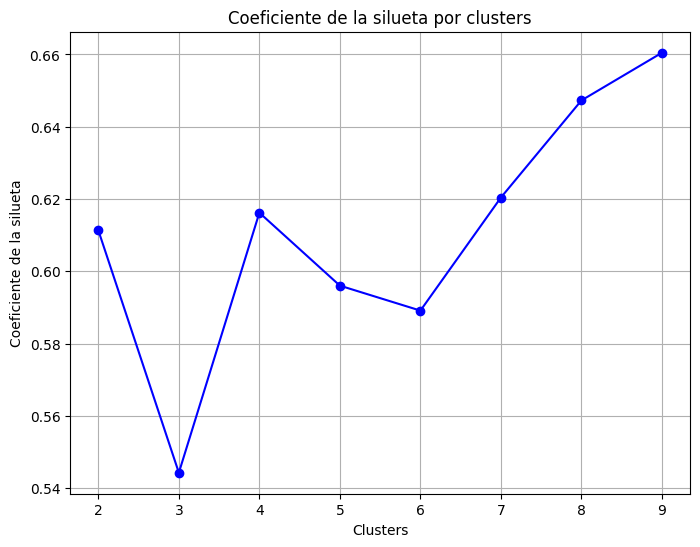

In [37]:


def kmeans(X, clusters):
    silhouette_scores = []

    for cluster in clusters:
        kmeans = KMeans(n_clusters=cluster, random_state=42, max_iter=10000)
        labels = kmeans.fit_predict(X)  # Ajustar el modelo y predecir los clusters
        score = silhouette_score(X, labels)
        silhouette_scores.append(score)
        plot_silhouette(X, labels, cluster)
        plot_centroid_radar(kmeans.cluster_centers_, cluster)  # Graficar los centroides

    return silhouette_scores

def plot_silhouette(X, labels, cluster):
    silhouette_vals = silhouette_samples(X, labels)
    y_lower, y_upper = 0, 0
    n_clusters = np.unique(labels).shape[0]
    plt.figure(figsize=(7, 5))

    for i in range(n_clusters):
        ith_cluster_silhouette_values = silhouette_vals[labels == i]
        ith_cluster_silhouette_values.sort()
        y_upper += len(ith_cluster_silhouette_values)
        color = cm.nipy_spectral(float(i) / n_clusters)
        plt.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values,
                          facecolor=color, edgecolor=color, alpha=0.7)
        y_lower = y_upper

    plt.axvline(x=np.mean(silhouette_vals), color="red", linestyle="--")
    plt.title(f'Grafica de silueta para el cluster {cluster}')
    plt.xlabel('Coeficiente de la silueta')
    plt.ylabel('Cluster')
    plt.tight_layout()
    plt.show()

def plot_silhouette_vs_cluster(clusters, silhouette_scores):
    plt.figure(figsize=(8, 6))
    plt.plot(clusters, silhouette_scores, marker='o', linestyle='-', color='b')
    plt.title('Coeficiente de la silueta por clusters')
    plt.xlabel('Clusters')
    plt.ylabel('Coeficiente de la silueta')
    plt.grid(True)
    plt.show()

def plot_centroid_radar(centroides, cluster):
    num_features = centroides.shape[1]
    angles = np.linspace(0, 2 * np.pi, num_features, endpoint=False).tolist()
    angles += angles[:1] 

    plt.figure(figsize=(8, 8))
    
    for i in range(centroides.shape[0]):
        values = centroides[i].tolist()
        values += values[:1]  
        plt.subplot(1, 1, 1)
        plt.fill(angles, values, alpha=0.25)
        plt.plot(angles, values, label=f'Cluster {i + 1}')

    plt.xticks(angles[:-1], [f'Feature {i + 1}' for i in range(num_features)])
    plt.title(f'Grafica para cluster {cluster}')
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

# Ejemplo de uso
from sklearn.datasets import make_blobs

# Especificamos los números de clusters a evaluar
clusters = range(2, 10)  

# Ejecutamos KMeans y graficamos los resultados
silhouette_scores = kmeans(df_clustering, clusters)
for cluster, score in zip(clusters, silhouette_scores):
    print(f'cluster = {cluster}, Puntaje de Silueta = {score}')
# Graficamos el coeficiente de silueta para cada número de clusters
plot_silhouette_vs_cluster(clusters, silhouette_scores)


In [41]:
def plot_centroid_spider_plotly(centroids, k):
    # Crear un DataFrame con los centroides
    num_features = centroids.shape[1]
    feature_labels = [f'Feature {i + 1}' for i in range(num_features)]
    
    # Preparar los datos para Plotly
    data = []
    for i in range(k):
        values = centroids[i].tolist() + [centroids[i][0]]  # Cerrar el círculo
        data.append(values)
    
    # Crear un DataFrame
    df = pd.DataFrame(data, columns=feature_labels + ['Feature 1'])
    df['Cluster'] = [f'Cluster {i + 1}' for i in range(k)]
    df = pd.melt(df, id_vars='Cluster', value_vars=feature_labels, var_name='Feature', value_name='Value')

    # Gráfico de araña (radar)
    fig = px.line_polar(df, r='Value', theta='Feature', color='Cluster', line_close=True,
                         title=f'Spider Plot for {k} Clusters')
    
    fig.update_traces(fill='toself', opacity=0.25)  # Rellenar el área
    fig.show()

kmeans = KMeans(n_clusters=9, random_state=42, max_iter=10000)
labels = kmeans.fit_predict(df_clustering_pca)

# Obtener los centroides
centroids = kmeans.cluster_centers_

# Graficar los centroides en un gráfico radial
plot_centroid_spider_plotly(centroids, 9)

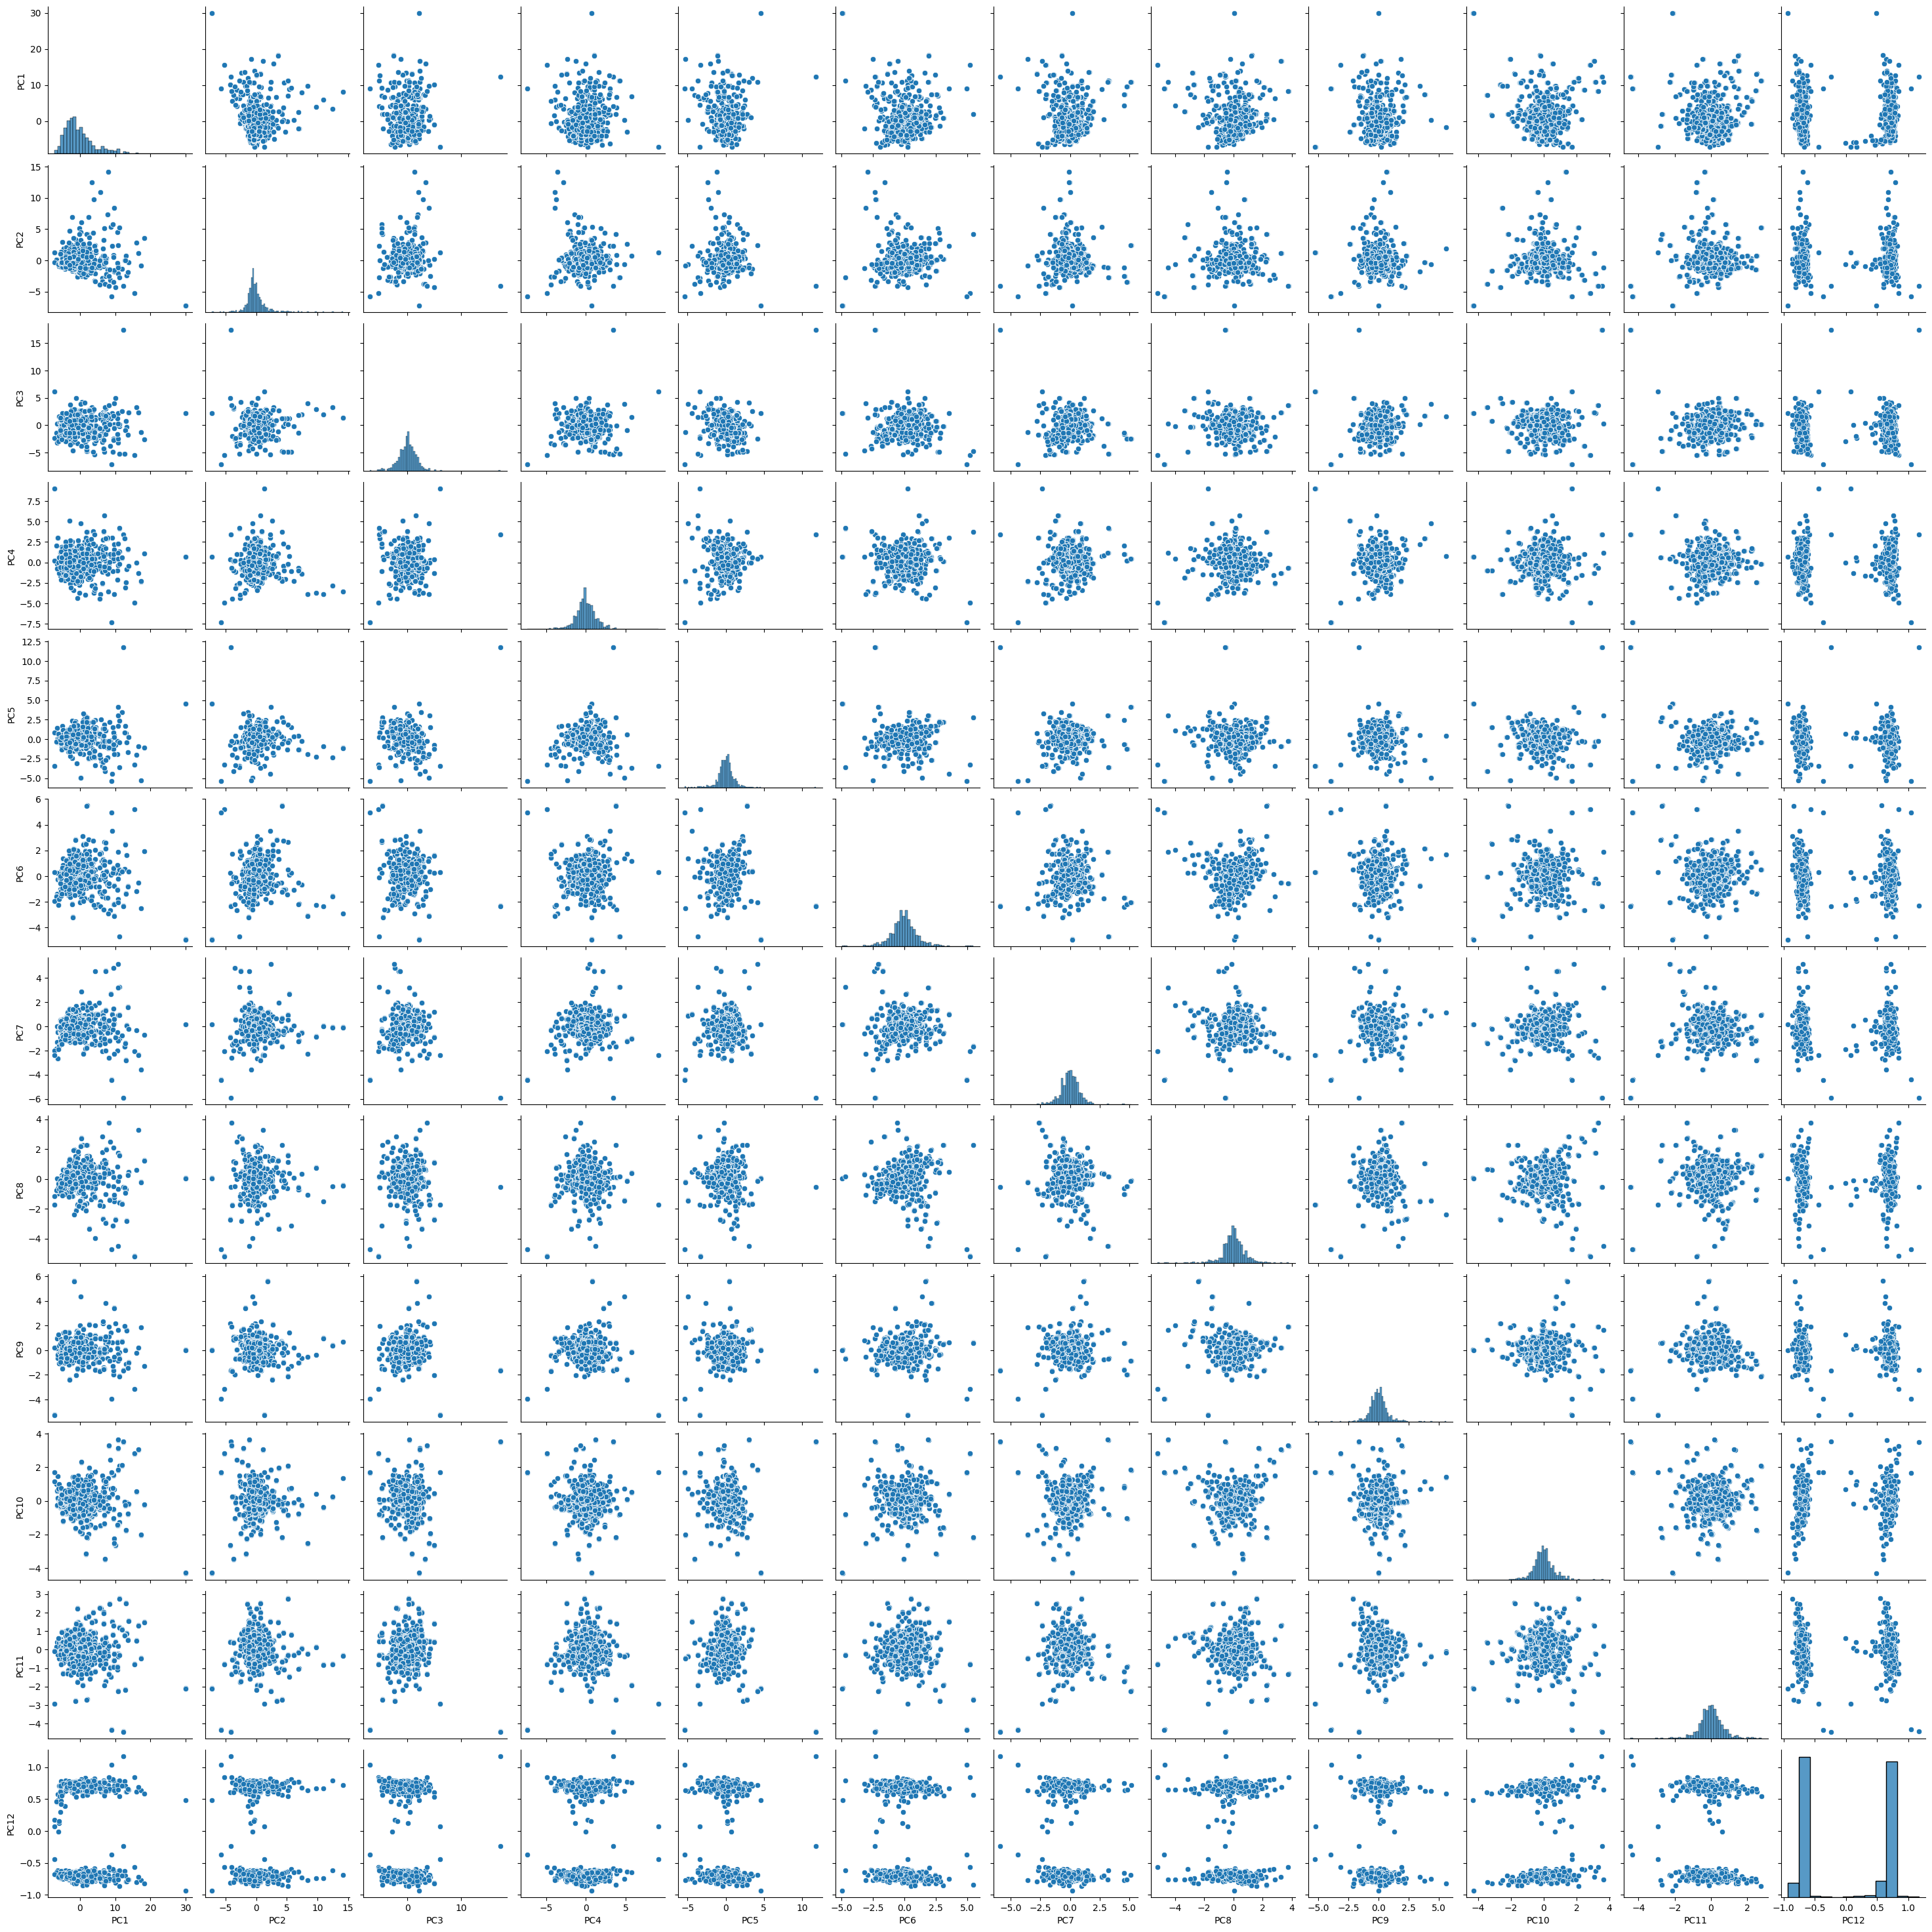

In [39]:
sns.pairplot(df_clustering_pca)
plt.show()

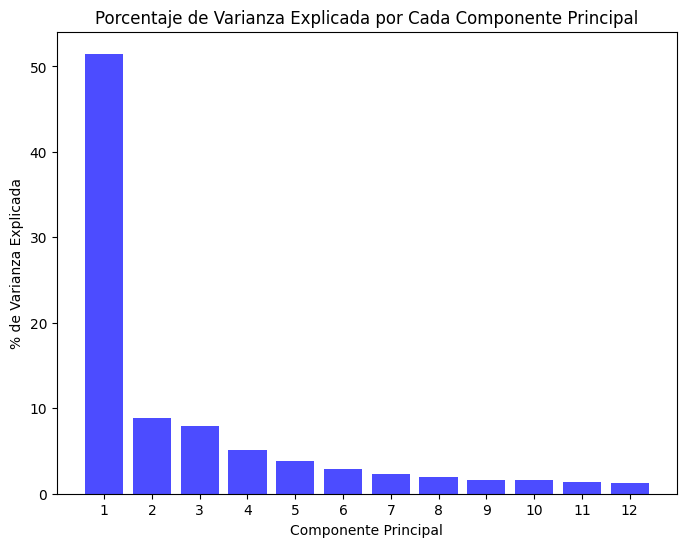

In [40]:
pca_model = pipeline.named_steps['pca']

# 1. Graficar el porcentaje de varianza explicada por cada componente
plt.figure(figsize=(8, 6))
plt.bar(np.arange(1, pca_model.n_components_ + 1), pca_model.explained_variance_ratio_ * 100, alpha=0.7, color='b')

# Etiquetas y título
plt.title('Porcentaje de Varianza Explicada por Cada Componente Principal')
plt.xlabel('Componente Principal')
plt.ylabel('% de Varianza Explicada')
plt.xticks(np.arange(1, pca_model.n_components_ + 1))  
plt.show()

### Conclusiones del modelo K-Means

Como se observa en el spider plot los clusters estan mejor definidos comparado con GMM